# 1 — Đọc dữ liệu

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

customers = pd.read_csv("/content/customers_silver.csv")
orders = pd.read_csv("/content/orders.csv")
order_details = pd.read_csv("/content/Order_items.csv")

/tmp/ipykernel_582/4048410252.py:8: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  order_details = pd.read_csv("/content/Order_items.csv")


# 2 — Kiểm tra Shape

In [59]:
print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Order Details:", order_details.shape)

Customers: (121930, 6)
Orders: (646945, 9)
Order Details: (714653, 7)


# 3 — Kiểm tra Columns

In [60]:
print("CUSTOMERS")
print(customers.columns.tolist())

print("\nORDERS")
print(orders.columns.tolist())

print("\nORDER DETAILS")
print(order_details.columns.tolist())

CUSTOMERS
['customer_id', 'zip', 'signup_date', 'gender', 'age_group', 'acquisition_channel']

ORDERS
['order_id', 'customer_id', 'sales_employee_id', 'order_date', 'order_source', 'order_status', 'device_type', 'comment', 'zip']

ORDER DETAILS
['order_id', 'product_id', 'promo_id', 'promo_id_2', 'quantity', 'unit_price', 'discount_amount']


# 4 — Kiểm tra Datatype

In [61]:
print("CUSTOMERS")
print(customers.dtypes)

print("\nORDERS")
print(orders.dtypes)

print("\nORDER DETAILS")
print(order_details.dtypes)

CUSTOMERS
customer_id             int64
zip                     int64
signup_date            object
gender                 object
age_group              object
acquisition_channel    object
dtype: object

ORDERS
order_id              int64
customer_id           int64
sales_employee_id    object
order_date           object
order_source         object
order_status         object
device_type          object
comment              object
zip                   int64
dtype: object

ORDER DETAILS
order_id             int64
product_id           int64
promo_id            object
promo_id_2          object
quantity             int64
unit_price         float64
discount_amount    float64
dtype: object


In [62]:
orders["order_date"] = pd.to_datetime(
    orders["order_date"],
    errors="coerce"
)

# 5 — Kiểm tra Missing Values

In [63]:
print("CUSTOMERS")
print(customers.isnull().sum())

print("\nORDERS")
print(orders.isnull().sum())

print("\nORDER DETAILS")
print(order_details.isnull().sum())

CUSTOMERS
customer_id            0
zip                    0
signup_date            0
gender                 0
age_group              0
acquisition_channel    0
dtype: int64

ORDERS
order_id             0
customer_id          0
sales_employee_id    0
order_date           0
order_source         0
order_status         0
device_type          0
comment              0
zip                  0
dtype: int64

ORDER DETAILS
order_id                0
product_id              0
promo_id           438344
promo_id_2         714447
quantity                0
unit_price              0
discount_amount         0
dtype: int64


# 6 — Kiểm tra Duplicate

In [64]:
print("Customers duplicate:", customers.duplicated().sum())
print("Orders duplicate:", orders.duplicated().sum())
print("Order Details duplicate:", order_details.duplicated().sum())

Customers duplicate: 0
Orders duplicate: 0
Order Details duplicate: 0


In [65]:
print(orders["order_id"].duplicated().sum())
print(customers["customer_id"].duplicated().sum())
print(order_details.duplicated(subset=["order_id", "product_id"]).sum())

0
0
0


# 7 — Kiểm tra quan hệ giữa các bảng

In [66]:
print("CustomerID trong Customers:")
print(customers['customer_id'].nunique())

print("CustomerID trong Orders:")
print(orders['customer_id'].nunique())

print("OrderID trong Orders:")
print(orders['order_id'].nunique())

print("OrderID trong OrderDetails:")
print(order_details['order_id'].nunique())

CustomerID trong Customers:
121930
CustomerID trong Orders:
90246
OrderID trong Orders:
646945
OrderID trong OrderDetails:
646945


In [67]:
order_details.groupby('order_id').size().describe()

,0
count,646945.000000
mean,1.104658
std,0.312776
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,5.000000


# 8 — Xác định Measure

In [68]:
# Measure phục vụ PS1
measures = [
    "CustomerID",
    "OrderID",
    "Quantity",
    "UnitPrice",
    "Discount",
    "OrderDate"
]

print("Measures:")
for col in measures:
    print("-", col)

Measures:
- CustomerID
- OrderID
- Quantity
- UnitPrice
- Discount
- OrderDate


# 9 — Tạo Revenue

In [69]:
order_details["Revenue"] = (order_details["quantity"] * order_details["unit_price"]- order_details["discount_amount"])
order_details[['order_id','quantity','unit_price','discount_amount','Revenue']].head()

,order_id,quantity,unit_price,discount_amount,Revenue
0,1,7,1138.22,0.0,7967.54
1,2,7,10166.25,0.0,71163.75
2,3,3,11220.33,0.0,33660.99
3,4,5,10639.25,0.0,53196.25
4,6,1,1597.84,0.0,1597.84


# 10 — JOIN Orders với OrderDetails

In [70]:
order_data = orders.merge(order_details,on='order_id',how="inner")
print(order_data.shape)
order_data.head()

(714653, 16)


,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount,Revenue
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109,2400,NaN,NaN,7,1138.22,0.0,7967.54
1,2,58621,EMP0180,2012-07-04,paid_search,returned,mobile,"Dịch vụ ổn định, nhân viên luôn sẵn sàng hỗ tr...",1330,609,NaN,NaN,7,10166.25,0.0,71163.75
2,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473,396,NaN,NaN,3,11220.33,0.0,33660.99
3,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360,635,NaN,NaN,5,10639.25,0.0,53196.25
4,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886,1935,NaN,NaN,1,1597.84,0.0,1597.84


In [71]:
print("Orders trước JOIN:",
      orders['order_id'].nunique())

print("Orders sau JOIN:",
      order_data['order_id'].nunique())

Orders trước JOIN: 646945
Orders sau JOIN: 646945


# 11 — Xử lý Order Status

In [72]:
orders['order_status'].value_counts()

,count
order_status,
delivered,516716
cancelled,59462
returned,36142
shipped,13773
paid,13577
created,7275


In [73]:
valid_orders = orders[
    orders['order_status'] == "delivered"
].copy()

In [74]:
order_data = valid_orders.merge(
    order_details,
    on='order_id',
    how="inner"
)
print(order_data.shape)
order_data.head()


(570874, 16)


,order_id,customer_id,sales_employee_id,order_date,order_source,order_status,device_type,comment,zip,product_id,promo_id,promo_id_2,quantity,unit_price,discount_amount,Revenue
0,1,58578,EMP0103,2012-07-04,paid_search,delivered,desktop,"Dịch vụ chăm sóc khách hàng chuyên nghiệp, thá...",1109,2400,NaN,NaN,7,1138.22,0.0,7967.54
1,3,58811,EMP0093,2012-07-04,direct,delivered,desktop,Khách hàng không có thêm phản hồi về chất lượn...,1473,396,NaN,NaN,3,11220.33,0.0,33660.99
2,4,59453,EMP0015,2012-07-04,referral,delivered,desktop,"Phản hồi thắc mắc đầy đủ, hỗ trợ xuyên suốt qu...",2360,635,NaN,NaN,5,10639.25,0.0,53196.25
3,6,57821,EMP0107,2012-07-06,email_campaign,delivered,mobile,Khách hàng đánh giá mức độ hài lòng ở mức khá.,2886,1935,NaN,NaN,1,1597.84,0.0,1597.84
4,7,57820,EMP0072,2012-07-06,organic_search,delivered,tablet,"Tư vấn chi tiết, thái độ chuyên nghiệp và thân...",2886,1934,NaN,NaN,6,1633.49,0.0,9800.94


# 12 — Metric 1: Customer Revenue

In [75]:
customer_revenue = (
    order_data
    .groupby("customer_id", as_index=False)
    ["Revenue"]
    .sum()
    .rename(columns={
        "Revenue": "CustomerRevenue"
    })
)

customer_revenue.head()

,customer_id,CustomerRevenue
0,1,98782.44
1,2,126255.29
2,3,12001.55
3,4,10939.06
4,5,64179.86


In [76]:
print(
    "Tổng Customer Revenue:",
    customer_revenue["CustomerRevenue"].sum()
)

print(
    "Tổng Revenue:",
    order_data["Revenue"].sum()
)

Tổng Customer Revenue: 12518175747.2
Tổng Revenue: 12518175747.199999


# 13 — Metric 2: Purchase Frequency

In [77]:
purchase_frequency = (
    order_data
    .groupby("customer_id")["order_id"]
    .nunique()
    .reset_index()
    .rename(columns={
        "order_id": "PurchaseFrequency"
    })
)

purchase_frequency.head()

,customer_id,PurchaseFrequency
0,1,4
1,2,2
2,3,2
3,4,1
4,5,5


# 14 — Tạo bảng Customer-level

In [78]:
customer_analysis = customer_revenue.merge(
    purchase_frequency,
    on="customer_id",
    how="outer"
)

customer_analysis.head()

,customer_id,CustomerRevenue,PurchaseFrequency
0,1,98782.44,4
1,2,126255.29,2
2,3,12001.55,2
3,4,10939.06,1
4,5,64179.86,5


In [79]:
print(customer_analysis.shape)

print(
    customer_analysis[
        ["CustomerRevenue", "PurchaseFrequency"]
    ].describe()
)

(85115, 3)
       CustomerRevenue  PurchaseFrequency
count     8.511500e+04       85115.000000
mean      1.470737e+05           6.070798
std       1.799374e+05           7.040892
min       4.456500e+02           1.000000
25%       2.854499e+04           1.000000
50%       7.973085e+04           3.000000
75%       1.982889e+05           8.000000
max       2.883271e+06          93.000000


# 15 — Tạo Customer Segment

In [80]:
revenue_median = customer_analysis["CustomerRevenue"].median()

frequency_median = customer_analysis["PurchaseFrequency"].median()

print("Revenue median:", revenue_median)
print("Frequency median:", frequency_median)

Revenue median: 79730.85
Frequency median: 3.0


In [81]:
customer_analysis["RevenueLevel"] = np.where(
    customer_analysis["CustomerRevenue"] >= revenue_median,
    "High",
    "Low"
)

customer_analysis["FrequencyLevel"] = np.where(
    customer_analysis["PurchaseFrequency"] >= frequency_median,
    "High",
    "Low"
)

In [82]:
customer_analysis[
    [
        "customer_id",
        "CustomerRevenue",
        "PurchaseFrequency",
        "RevenueLevel",
        "FrequencyLevel"
    ]
].head()

,customer_id,CustomerRevenue,PurchaseFrequency,RevenueLevel,FrequencyLevel
0,1,98782.44,4,High,High
1,2,126255.29,2,High,Low
2,3,12001.55,2,Low,Low
3,4,10939.06,1,Low,Low
4,5,64179.86,5,Low,High


In [83]:
def classify_customer(row):
    if (
        row["CustomerRevenue"] >= revenue_median
        and row["PurchaseFrequency"] >= frequency_median
    ):
        return "High Revenue - High Frequency"

    elif (
        row["CustomerRevenue"] >= revenue_median
        and row["PurchaseFrequency"] < frequency_median
    ):
        return "High Revenue - Low Frequency"

    elif (
        row["CustomerRevenue"] < revenue_median
        and row["PurchaseFrequency"] >= frequency_median
    ):
        return "Low Revenue - High Frequency"

    else:
        return "Low Revenue - Low Frequency"

In [84]:
customer_analysis["Segment"] = customer_analysis.apply(
    classify_customer,
    axis=1
)
customer_analysis.head()

,customer_id,CustomerRevenue,PurchaseFrequency,RevenueLevel,FrequencyLevel,Segment
0,1,98782.44,4,High,High,High Revenue - High Frequency
1,2,126255.29,2,High,Low,High Revenue - Low Frequency
2,3,12001.55,2,Low,Low,Low Revenue - Low Frequency
3,4,10939.06,1,Low,Low,Low Revenue - Low Frequency
4,5,64179.86,5,Low,High,Low Revenue - High Frequency


# 16 — KPI 1: Customer Distribution by Segment (Số lượng và tỷ lệ khách hàng trong từng phân khúc)

In [85]:
kpi_customer_distribution = (
    customer_analysis
    .groupby("Segment")
    .agg(
        CustomerCount=("customer_id", "nunique")
    )
    .reset_index()
)

total_customers = customer_analysis["customer_id"].nunique()

kpi_customer_distribution["CustomerShare"] = (
    kpi_customer_distribution["CustomerCount"]
    / total_customers
    * 100
)

kpi_customer_distribution

,Segment,CustomerCount,CustomerShare
0,High Revenue - High Frequency,39955,46.942372
1,High Revenue - Low Frequency,2603,3.058215
2,Low Revenue - High Frequency,9769,11.477413
3,Low Revenue - Low Frequency,32788,38.522000


# 17 — KPI 2 : Doanh thu theo Segment (Doanh thu của từng phân khúc / Tổng doanh thu)

In [86]:
kpi_revenue_segment = (
    customer_analysis
    .groupby("Segment")
    .agg(
        SegmentRevenue=("CustomerRevenue", "sum")
    )
    .reset_index()
)

total_revenue = customer_analysis["CustomerRevenue"].sum()

kpi_revenue_segment["RevenueContribution"] = (
    kpi_revenue_segment["SegmentRevenue"]
    / total_revenue
    * 100
)

kpi_revenue_segment

,Segment,SegmentRevenue,RevenueContribution
0,High Revenue - High Frequency,1.086865e+10,86.822966
1,High Revenue - Low Frequency,2.702192e+08,2.158615
2,Low Revenue - High Frequency,5.099985e+08,4.074064
3,Low Revenue - Low Frequency,8.693065e+08,6.944355


# 18 — KPI 3: Average Purchase Frequency by Segment (Purchase Frequency trung bình của từng phân khúc)

In [87]:
kpi_frequency_segment = (
    customer_analysis
    .groupby("Segment")
    .agg(
        AveragePurchaseFrequency=(
            "PurchaseFrequency",
            "mean"
        )
    )
    .reset_index()
)

kpi_frequency_segment

,Segment,AveragePurchaseFrequency
0,High Revenue - High Frequency,10.813165
1,High Revenue - Low Frequency,1.732616
2,Low Revenue - High Frequency,3.760569
3,Low Revenue - Low Frequency,1.324539


# 19 — KPI 4: Customer Revenue by Segment (Tổng Customer Revenue của từng phân khúc)

In [88]:
kpi_customer_revenue_segment = (
    customer_analysis
    .groupby("Segment")
    .agg(
        TotalCustomerRevenue=(
            "CustomerRevenue",
            "sum"
        )
    )
    .reset_index()
)

kpi_customer_revenue_segment

,Segment,TotalCustomerRevenue
0,High Revenue - High Frequency,1.086865e+10
1,High Revenue - Low Frequency,2.702192e+08
2,Low Revenue - High Frequency,5.099985e+08
3,Low Revenue - Low Frequency,8.693065e+08


# 20 — Tạo bảng KPI tổng hợp

In [89]:
kpi_ps1 = (
    kpi_customer_distribution
    .merge(
        kpi_revenue_segment,
        on="Segment",
        how="outer"
    )
    .merge(
        kpi_frequency_segment,
        on="Segment",
        how="outer"
    )
    .merge(
        kpi_customer_revenue_segment,
        on="Segment",
        how="outer"
    )
)

kpi_ps1

,Segment,CustomerCount,CustomerShare,SegmentRevenue,RevenueContribution,AveragePurchaseFrequency,TotalCustomerRevenue
0,High Revenue - High Frequency,39955,46.942372,1.086865e+10,86.822966,10.813165,1.086865e+10
1,High Revenue - Low Frequency,2603,3.058215,2.702192e+08,2.158615,1.732616,2.702192e+08
2,Low Revenue - High Frequency,9769,11.477413,5.099985e+08,4.074064,3.760569,5.099985e+08
3,Low Revenue - Low Frequency,32788,38.522000,8.693065e+08,6.944355,1.324539,8.693065e+08


# 21 — Visualization

# Biểu đồ 1: Số lượng khách hàng theo Segment

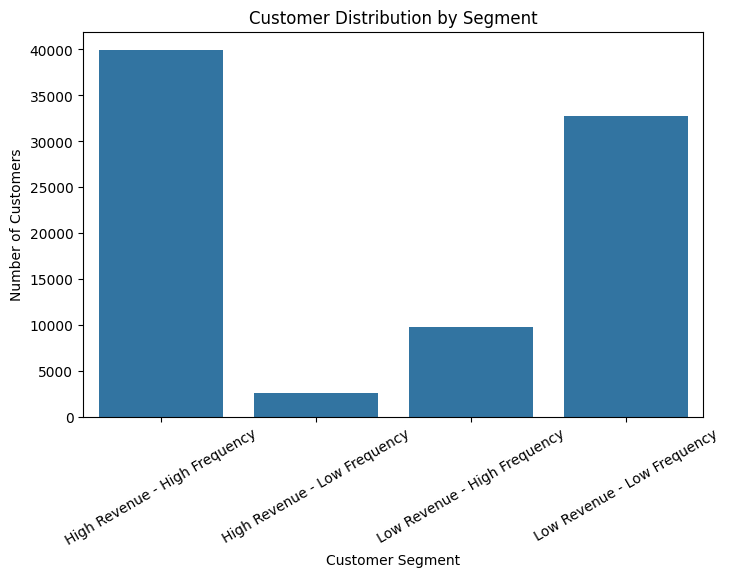

In [90]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=kpi_ps1,
    x="Segment",
    y="CustomerCount"
)

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30)
plt.show()

# Biểu đồ 2: Revenue Contribution

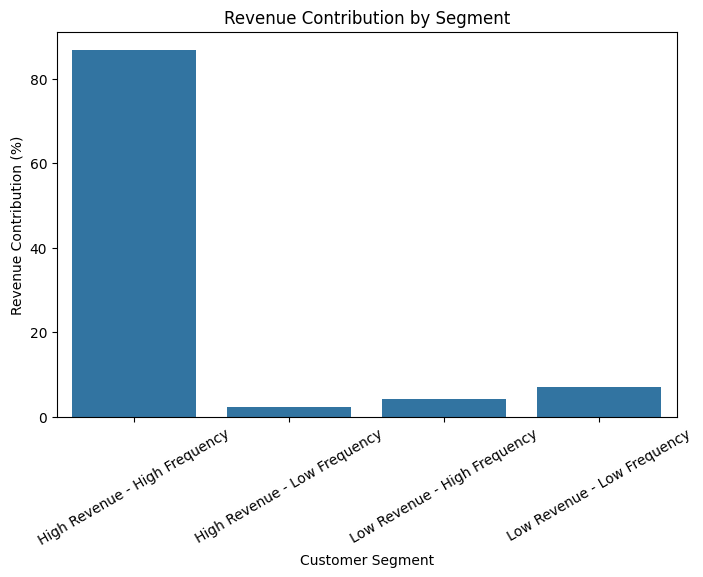

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=kpi_ps1,
    x="Segment",
    y="RevenueContribution"
)

plt.title("Revenue Contribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Revenue Contribution (%)")
plt.xticks(rotation=30)
plt.show()

# Biểu đồ 3: Customer Revenue × Purchase Frequency

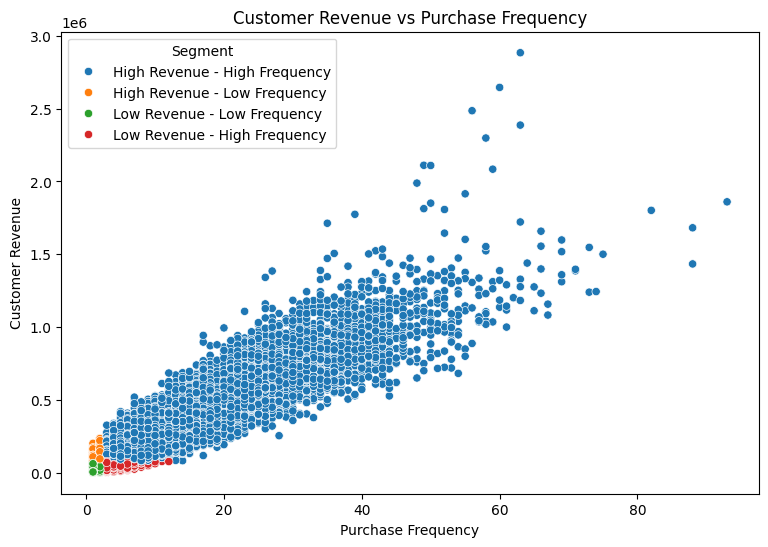

In [92]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=customer_analysis,
    x="PurchaseFrequency",
    y="CustomerRevenue",
    hue="Segment"
)

plt.title(
    "Customer Revenue vs Purchase Frequency"
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Customer Revenue")

plt.show()

# 22 — Kiểm tra kết quả

In [93]:
print(
    "Duplicate CustomerID:",
    customer_analysis["customer_id"].duplicated().sum()
)

Duplicate CustomerID: 0


In [94]:
print(
    customer_analysis["Segment"].isnull().sum()
)

0


In [95]:
print(
    customer_analysis["PurchaseFrequency"].min()
)

1


In [96]:
print(
    kpi_ps1["CustomerShare"].sum()
)

100.0


In [97]:
print(
    kpi_ps1["RevenueContribution"].sum()
)

100.0
